# Predicting Ocean pH Under Rising CO₂

Physics-based model of surface-ocean pH and aragonite saturation, driven by atmospheric CO₂, with scenario projections to 2100, parameter-uncertainty bands, hold-out validation, and a sensor simulation.

All logic lives in **`ocean_ph_model.py`** (importable from a web backend). This notebook is the walkthrough.

**What changed from the first version**
- The Henderson–Hasselbalch ratio is replaced by a full carbonate-system solver (CO₂, bicarbonate, carbonate, borate, water), so buffering is handled.
- The pH projection is driven by an explicit CO₂ scenario that starts where the history ends (no more hand-picked slope).
- Uncertainty bands, a chronological train/test split, and data-quality checks were added.
- The sensor model is tied to the pH series, uses seawater-range calibration, and shows when a trend becomes detectable.
- No more `df` overwriting, fragile column detection, or unused columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ocean_ph_model as m

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})

params = m.OceanParams()      # global-mean surface box: TA 2300 umol/kg, 18 C, S 35
params

OceanParams(ta_umol_kg=2300.0, temp_c=18.0, salinity=35.0, equilibration=0.891, pco2_ref_ppm=278.0, warming_c_per_decade=0.0)

## 1. Data and quality checks

`check_observations` compares a series against the reference CO₂ record and against what carbonate chemistry predicts. To use real data, drop in:

- NOAA Mauna Loa annual means (`co2_annmean_mlo.csv` from NOAA GML): `m.load_noaa_co2_annual("data/co2_annmean_mlo.csv")`, then `m.calibrate_equilibration()` and put the result in `OceanParams(equilibration=...)`.
- Any observed pH series with `year` and `pH` columns (Copernicus Marine global mean, Station ALOHA, BATS, ...).

The file below is the original dataset from the first version of this project.

In [2]:
OBS_PATH = "data/ocean_acidification_dataset.csv"      # swap for a real series
obs = m.load_observations(OBS_PATH)
print(f"{len(obs)} rows, {obs.year.min()}-{obs.year.max()}\n")
for w in m.check_observations(obs, params):
    print(f"[{w['level'].upper():7}] {w['message']}")

46 rows, 1980-2025

[WARNING] CO2 differs from the reference Mauna Loa record by 10.1 ppm on average (bias +10.0 ppm; 2025: 436.5 vs ~426.6 ppm).
[WARNING] Annual-mean CO2 falls by more than 0.5 ppm in 2 year(s); the Mauna Loa annual mean rises in essentially every year, so this looks like noise or synthetic data.
[INFO   ] Observed pH trend: -0.00099 per year over 1980-2025 (global surface-ocean trend since 1985 is about -0.0017 per year).
[WARNING] The series' pH response to CO2 (-0.39 per log10 unit) is 52% of what carbonate chemistry predicts here (-0.77). For a global-mean series this is inconsistent; regional or coastal series can legitimately differ.


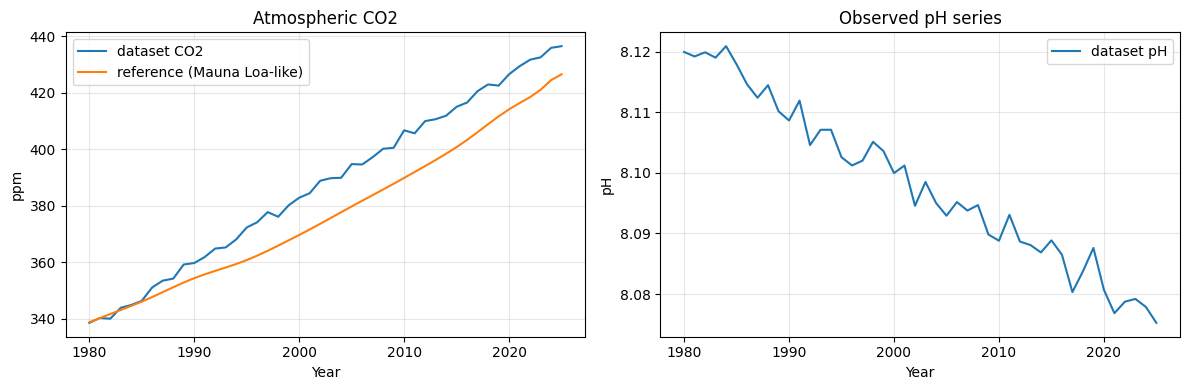

In [3]:
ref = m.co2_history(obs.year.min(), obs.year.max())
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(obs.year, obs.co2_ppm, label="dataset CO2"); ax[0].plot(ref.index, ref.values, label="reference (Mauna Loa-like)")
ax[0].set(title="Atmospheric CO2", xlabel="Year", ylabel="ppm"); ax[0].legend()
ax[1].plot(obs.year, obs.ph, label="dataset pH")
ax[1].set(title="Observed pH series", xlabel="Year", ylabel="pH"); ax[1].legend()
plt.tight_layout()

## 2. Chemistry: why constant bicarbonate is not enough

Henderson–Hasselbalch with fixed bicarbonate gives exactly **−1.0 pH per decade-of-CO₂** (log₁₀ unit). Real seawater buffers: dissolving CO₂ also changes carbonate and bicarbonate, so the response is smaller and depends on temperature and alkalinity. The Revelle factor measures that buffering (typically about 8–14 at the surface).

Carbonate-system sensitivity: -0.87 pH per log10(CO2)   (H-H constant bicarbonate: -1.00)
Revelle factor at 380 ppm, 18 C: 10.6


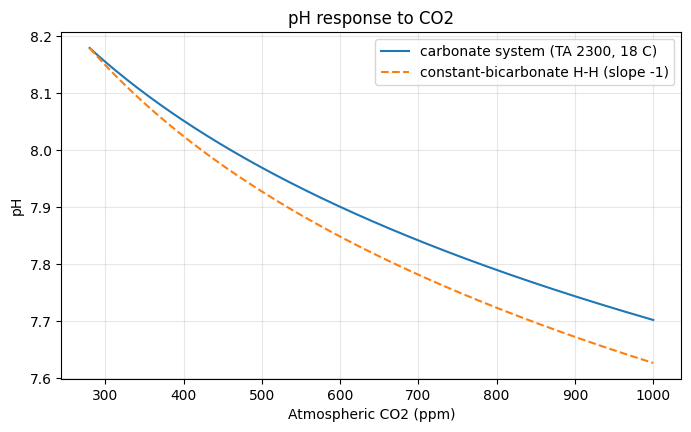

In [4]:
x = np.linspace(280, 1000, 200)
ph = m.solve_carbonate(2300, m.xco2_to_pco2(x, 18, 35), 18, 35)["pH"]
plt.plot(x, ph, label="carbonate system (TA 2300, 18 C)")
plt.plot(x, ph[0] - np.log10(x / x[0]), "--", label="constant-bicarbonate H-H (slope -1)")
plt.xlabel("Atmospheric CO2 (ppm)"); plt.ylabel("pH"); plt.legend(); plt.title("pH response to CO2")

slope = np.polyfit(np.log10(x), ph, 1)[0]
print(f"Carbonate-system sensitivity: {slope:.2f} pH per log10(CO2)   (H-H constant bicarbonate: -1.00)")
print(f"Revelle factor at 380 ppm, 18 C: {float(m.revelle_factor(2300, 380, 18, 35)):.1f}")

## 3. Reconstruction 1850 → today

One tunable parameter, `equilibration` (how much of the atmospheric CO₂ rise the surface water has caught up with), is calibrated to the observed global surface-ocean trend of about −0.0017 pH/yr (Copernicus Marine, 1985–2022). The change since pre-industrial times is **not** fitted, so it works as an independent check.

Model pH trend 1985-2022: -0.00170 per year   (calibration target: -0.0017)
Model pH change 1850 -> 2022: -0.125   (Copernicus quotes about -0.1, rounded)
pH 1850 / 1985 / 2025: 8.175 / 8.112 / 8.043
[H+] increase vs pre-industrial by 2025: 38%


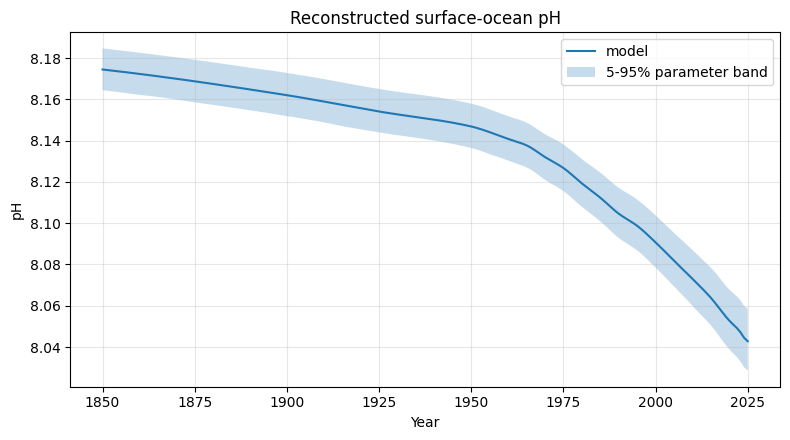

In [5]:
hist = m.project("intermediate", params, end=2025)
h = hist.set_index("year")

fit = h.loc[1985:2022]
trend = np.polyfit(fit.index, fit.pH, 1)[0]
print(f"Model pH trend 1985-2022: {trend:+.5f} per year   (calibration target: -0.0017)")
print(f"Model pH change 1850 -> 2022: {h.loc[2022,'pH'] - h.loc[1850,'pH']:+.3f}   (Copernicus quotes about -0.1, rounded)")
print(f"pH 1850 / 1985 / 2025: {h.loc[1850,'pH']:.3f} / {h.loc[1985,'pH']:.3f} / {h.loc[2025,'pH']:.3f}")
print(f"[H+] increase vs pre-industrial by 2025: {h.loc[2025,'acidity_change_pct']:.0f}%")

fig, ax = plt.subplots()
ax.plot(hist.year, hist.pH, label="model"); ax.fill_between(hist.year, hist.pH_lo, hist.pH_hi, alpha=.25, label="5-95% parameter band")
ax.set(title="Reconstructed surface-ocean pH", xlabel="Year", ylabel="pH"); ax.legend()
plt.tight_layout()

## 4. Hold-out validation on the supplied series

Fit on years ≤ 2005, score on 2006–2025 (never shuffled). The physics model only fits one number (alkalinity) on the training years; the empirical models are the usual statistical baselines.

In [6]:
val = m.validate(obs, params, split_year=2005)
print(val.round(4).to_string(index=False))

                           model  test_RMSE  test_MAE  test_bias
      empirical: pH ~ log10(CO2)     0.0022    0.0017    -0.0008
       empirical: linear in time     0.0037    0.0030    -0.0029
           baseline: persistence     0.0094    0.0077     0.0072
physics model (fitted TA = 2382)     0.0219    0.0214    -0.0214


**Reading this table.** On *this* file, the empirical regression wins and the physics model is worst (RMSE about 0.022). That is a data signal, not a model failure: section 1 showed the file's pH falls only about half as fast as carbonate chemistry says it should for its own CO₂ column, so no physically consistent model can fit it. With a real series (Copernicus, ALOHA, BATS), rerun this cell. If the data are consistent with the chemistry, the physics model should come close to the empirical fit on the hold-out years, and it is the only one of the models here that can sensibly extrapolate to 2100.

## 5. Scenario projections to 2100

Four illustrative CO₂ pathways (rounded, SSP-like; load the official concentration files with `m.load_scenario_csv` for publication). The band is *parameter* uncertainty (alkalinity ±40 µmol/kg, temperature ±1.5 °C, equilibration ±0.05); it does not include scenario choice or natural variability.

    scenario  CO2_2100  pH_2050  pH_2100  dpH_vs_2025  acidity_vs_preind_%  omega_arag_2100
         low     432.0    8.029    8.039       -0.004               39.236            2.635
intermediate     600.0    7.999    7.924       -0.119               81.296            2.115
        high     850.0    7.981    7.796       -0.247              143.229            1.638
   very_high    1100.0    7.958    7.698       -0.344              204.772            1.338


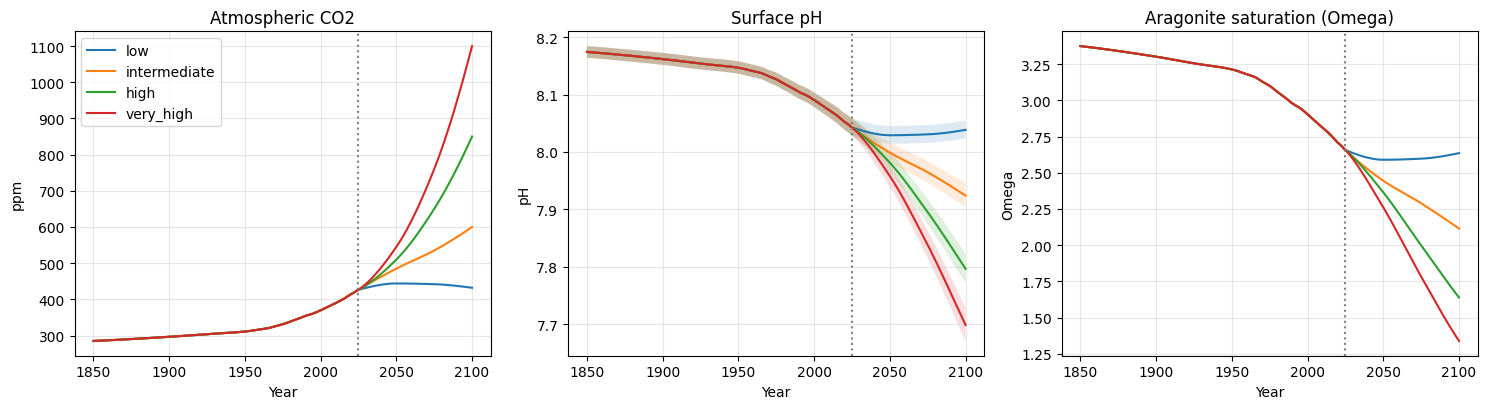

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
rows = []
for name, spec in m.SCENARIOS.items():
    d = m.project(name, params)
    ax[0].plot(d.year, d.co2_ppm, label=name)
    ax[1].plot(d.year, d.pH, label=name); ax[1].fill_between(d.year, d.pH_lo, d.pH_hi, alpha=.15)
    ax[2].plot(d.year, d.omega_arag, label=name)
    r = d.set_index("year")
    rows.append({"scenario": name, "CO2_2100": r.loc[2100, "co2_ppm"], "pH_2050": r.loc[2050, "pH"],
                 "pH_2100": r.loc[2100, "pH"], "dpH_vs_2025": r.loc[2100, "pH"] - r.loc[2025, "pH"],
                 "acidity_vs_preind_%": r.loc[2100, "acidity_change_pct"], "omega_arag_2100": r.loc[2100, "omega_arag"]})
for a, t, y in zip(ax, ["Atmospheric CO2", "Surface pH", "Aragonite saturation (Omega)"], ["ppm", "pH", "Omega"]):
    a.set(title=t, xlabel="Year", ylabel=y); a.axvline(2025, color="grey", ls=":")
ax[0].legend(); plt.tight_layout()
print(pd.DataFrame(rows).round(3).to_string(index=False))

In [8]:
# Sensitivity check: sea-surface warming of +0.2 C/decade after 2025
b = m.project("intermediate", params, n_mc=0).set_index("year").loc[2100]
w = m.project("intermediate", m.OceanParams(warming_c_per_decade=0.2), n_mc=0).set_index("year").loc[2100]
print(f"2100, intermediate scenario: pH {b.pH:.3f} -> {w.pH:.3f} ({w.pH-b.pH:+.3f}),  Omega {b.omega_arag:.2f} -> {w.omega_arag:.2f}")
print("Warming barely moves pH here because surface pCO2 is tied to the atmosphere; its indirect effects "
      "(circulation, stratification, alkalinity, biology) are not modelled.")

2100, intermediate scenario: pH 7.924 -> 7.925 (+0.001),  Omega 2.11 -> 2.24
Warming barely moves pH here because surface pCO2 is tied to the atmosphere; its indirect effects (circulation, stratification, alkalinity, biology) are not modelled.


## 6. Sensor simulation

A potentiometric electrode has an ideal slope of −ln(10)·R·T/F ≈ −0.057 V/pH at 18 °C. This section calibrates one in the seawater range (pH 7–8.5), measures the *modelled* pH series through it, and asks how long a trend takes to emerge from noise and drift.

Calibration: slope -56.7 mV/pH (98.2% of Nernst), residual 0.22 mV = 0.0039 pH

True model trend 1985-2025: -0.00173 pH/yr
Sensor trend (no drift): -0.00172 pH/yr
Sensor trend (0.1 mV/yr drift): -0.00348 pH/yr
A drift of only 0.10 mV/yr equals the entire observed acidification trend.


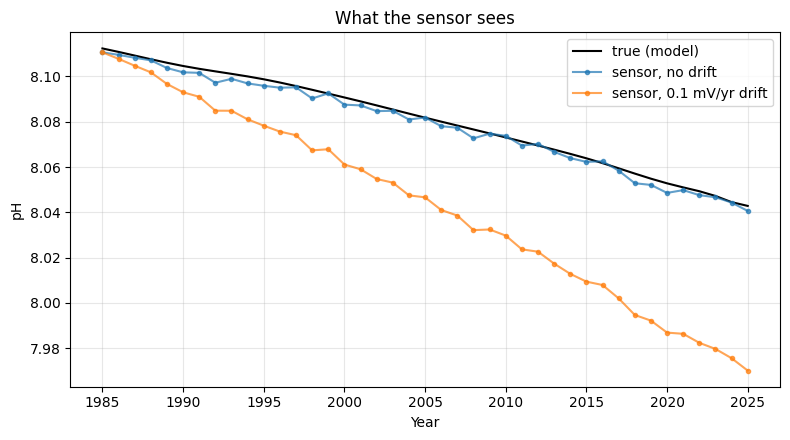

In [9]:
sensor = m.SensorParams(noise_mv=0.3, drift_mv_per_year=0.0)
cal = m.calibrate_sensor(sensor)
print(f"Calibration: slope {cal.slope_v_per_ph*1e3:.1f} mV/pH ({cal.efficiency_pct:.1f}% of Nernst), "
      f"residual {cal.rmse_mv:.2f} mV = {cal.rmse_ph:.4f} pH")

truth = m.project("intermediate", params, start=1985, end=2025, n_mc=0)
t = (truth.year - 1985).values
rows = []
for label, s in [("no drift", m.SensorParams(noise_mv=0.3)),
                 ("0.1 mV/yr drift", m.SensorParams(noise_mv=0.3, drift_mv_per_year=0.1))]:
    est = np.mean([m.measure(s, cal, truth.pH.values, t_years=t, seed=i) for i in range(12)], axis=0)  # 12 readings/yr
    rows.append((label, np.polyfit(truth.year, est, 1)[0], est))
true_slope = np.polyfit(truth.year, truth.pH, 1)[0]
print(f"\nTrue model trend 1985-2025: {true_slope:+.5f} pH/yr")
for label, sl, _ in rows:
    print(f"Sensor trend ({label}): {sl:+.5f} pH/yr")
print(f"A drift of only {0.0017*abs(sensor.slope_v_per_ph)*1e3:.2f} mV/yr equals the entire observed acidification trend.")

plt.plot(truth.year, truth.pH, "k", label="true (model)")
for label, _, est in rows: plt.plot(truth.year, est, ".-", alpha=.7, label=f"sensor, {label}")
plt.xlabel("Year"); plt.ylabel("pH"); plt.legend(); plt.title("What the sensor sees")
plt.tight_layout()

In [10]:
rows = []
for noise_ph in [0.002, 0.005, 0.01, 0.02, 0.088]:
    rows.append({"noise per reading (pH)": noise_ph,
                 "years to detect, 1 reading/yr": m.years_to_detect_trend(noise_ph),
                 "years to detect, 12 readings/yr": m.years_to_detect_trend(noise_ph, readings_per_year=12)})
print(pd.DataFrame(rows).to_string(index=False))
print("\n(trend -0.0017 pH/yr, detection = trend > 2 standard errors, independent noise, no drift;"
      " 0.088 pH is the 5 mV noise used in the first version of this project)")

 noise per reading (pH)  years to detect, 1 reading/yr  years to detect, 12 readings/yr
                  0.002                              5                                3
                  0.005                              8                                4
                  0.010                             12                                6
                  0.020                             19                                9
                  0.088                             51                               23

(trend -0.0017 pH/yr, detection = trend > 2 standard errors, independent noise, no drift; 0.088 pH is the 5 mV noise used in the first version of this project)


## 7. Export for the website

`project()` returns a flat table, and `projection_to_records()` turns it into JSON-ready dicts. This cell writes one file with every scenario plus metadata.

In [11]:
import json, os
os.makedirs("export", exist_ok=True)
payload = {
    "meta": {"params": params.to_dict(),
             "scenarios": {k: v["label"] for k, v in m.SCENARIOS.items()},
             "notes": "Global-mean surface box model. Band = parameter uncertainty only. Scenario CO2 paths are illustrative."},
    "projections": {}, "headline": {},
}
for name in m.SCENARIOS:
    d = m.project(name, params, n_mc=300)
    payload["projections"][name] = m.projection_to_records(d)
    payload["headline"][name] = m.headline_stats(d)
with open("export/projections.json", "w") as f:
    json.dump(payload, f)
print(f"export/projections.json: {os.path.getsize('export/projections.json')/1024:.0f} KB")
print(json.dumps(payload["headline"]["intermediate"], indent=2))

export/projections.json: 257 KB
{
  "pH_1850": 8.175,
  "pH_2025": 8.043,
  "pH_2100": 7.924,
  "pH_change_1850_to_now": -0.132,
  "pH_change_now_to_2100": -0.119,
  "acidity_change_pct_2100": 81.3,
  "omega_arag_2025": 2.66,
  "omega_arag_2100": 2.11,
  "co2_ppm_2100": 600.0
}


## Assumptions and limits (show these on the site)

- **Global-mean surface box.** Real pH varies by region (cold water, upwelling zones and coastal waters differ from the global mean by tenths of a pH unit).
- **Constant alkalinity and salinity**, constant temperature unless `warming_c_per_decade` is set. Sulfate, fluoride, phosphate and silicate alkalinity terms are neglected; cross-check against PyCO2SYS before publishing numbers.
- **Surface water lags the atmosphere** by a single factor, `equilibration`, calibrated to the observed 1985–2022 trend and assumed constant in the future.
- **Scenario CO₂ paths** are rounded illustrations of SSP-like pathways, and the 1850–1950 history is approximate (±2 ppm).
- **Bands are parameter uncertainty**, not forecast skill, scenario spread, or natural variability.
- **The supplied dataset fails the checks in section 1**, so validation here demonstrates the pipeline, not the model's accuracy. Replace it with observed data.